# Task 2.2: Reproduction of One Contribution from the Selected Paper

**Contribution being reproduced:** the LASVM-I filtering rule from Section 6, where the online learner only processes points whose margin lies in the active interval `s \le z \le 1`.  
**Evaluation metric:** prediction accuracy on the held-out test set, because Table 3 of the paper reports prediction accuracy for several datasets. I also track AUC and processed-example count as secondary diagnostics.

In [1]:

from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_approximation import RBFSampler
from sklearn.metrics import accuracy_score, roc_auc_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

SEEDS = [11, 23, 42, 57, 89]
DATA_NOISE = 0.22
LABEL_FLIP_RATE = 0.12
N_SAMPLES = 1200
TEST_SIZE = 0.20
VAL_SIZE = 0.20
GAMMA_GRID = [0.5, 1.0, 2.0]
SELECTED_GAMMA = 2.0
N_COMPONENTS = 500
LEARNING_RATE = 0.03
WEIGHT_DECAY = 1e-4
FULL_S = -1.0
FAILURE_S = 0.25
PAPER_BANANA_ACCURACY = 89.84

cwd = Path.cwd()
if (cwd / "results").exists() and (cwd / "data").exists():
    PARTB_DIR = cwd
elif (cwd / "partB").exists():
    PARTB_DIR = cwd / "partB"
else:
    PARTB_DIR = cwd
RESULTS_DIR = PARTB_DIR / "results"
DATA_DIR = PARTB_DIR / "data"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)


def build_dataset(seed, label_flip_rate=LABEL_FLIP_RATE, data_noise=DATA_NOISE):
    X, y = make_moons(n_samples=N_SAMPLES, noise=data_noise, random_state=42)
    X_train, X_temp, y_train_clean, y_temp = train_test_split(
        X, y, test_size=TEST_SIZE + VAL_SIZE, stratify=y, random_state=seed
    )
    relative_test_size = TEST_SIZE / (TEST_SIZE + VAL_SIZE)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=relative_test_size, stratify=y_temp, random_state=seed
    )

    rng = np.random.default_rng(seed)
    flip_count = int(label_flip_rate * len(y_train_clean))
    flip_idx = np.sort(rng.choice(len(y_train_clean), size=flip_count, replace=False))

    y_train_observed = y_train_clean.copy()
    y_train_observed[flip_idx] = 1 - y_train_observed[flip_idx]
    was_flipped = np.zeros(len(y_train_clean), dtype=bool)
    was_flipped[flip_idx] = True

    scaler = StandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    return {
        "seed": seed,
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "X_train_scaled": X_train_scaled,
        "X_val_scaled": X_val_scaled,
        "X_test_scaled": X_test_scaled,
        "y_train_clean": y_train_clean,
        "y_train_observed": y_train_observed,
        "y_val": y_val,
        "y_test": y_test,
        "was_flipped": was_flipped,
        "scaler": scaler,
    }


def validate_gamma(seeds=SEEDS, gammas=GAMMA_GRID, s=FULL_S):
    rows = []
    for gamma in gammas:
        for seed in seeds:
            split = build_dataset(seed)
            result = train_filtered_online_svm(
                split,
                gamma=gamma,
                s=s,
                n_components=N_COMPONENTS,
                learning_rate=LEARNING_RATE,
                weight_decay=WEIGHT_DECAY,
            )
            rows.append({
                "gamma": gamma,
                "seed": seed,
                "val_accuracy": result["val_accuracy"],
                "val_auc": result["val_auc"],
            })
    frame = pd.DataFrame(rows)
    summary = frame.groupby("gamma", as_index=False).agg(
        mean_val_accuracy=("val_accuracy", "mean"),
        std_val_accuracy=("val_accuracy", "std"),
        mean_val_auc=("val_auc", "mean"),
    )
    return frame, summary


def decision_scores(artifacts, X_raw):
    X_scaled = artifacts["scaler"].transform(X_raw)
    Phi = artifacts["feature_map"].transform(X_scaled)
    return Phi @ artifacts["weights"]


def train_filtered_online_svm(
    split,
    gamma=SELECTED_GAMMA,
    s=FULL_S,
    n_components=N_COMPONENTS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    process_confident=False,
):
    feature_map = RBFSampler(gamma=gamma, n_components=n_components, random_state=split["seed"])
    Phi_train = feature_map.fit_transform(split["X_train_scaled"])
    Phi_val = feature_map.transform(split["X_val_scaled"])
    Phi_test = feature_map.transform(split["X_test_scaled"])

    y_pm = np.where(split["y_train_observed"] == 1, 1.0, -1.0)
    weights = np.zeros(Phi_train.shape[1], dtype=float)

    processed = 0
    skipped_left = 0
    skipped_right = 0

    start = time.perf_counter()
    for x_i, y_i in zip(Phi_train, y_pm):
        z = y_i * float(np.dot(weights, x_i))
        if z < s:
            skipped_left += 1
            continue
        if z > 1.0 and not process_confident:
            skipped_right += 1
            continue

        processed += 1
        weights *= (1.0 - learning_rate * weight_decay)
        if z <= 1.0:
            weights += learning_rate * y_i * x_i
    runtime = time.perf_counter() - start

    val_scores = Phi_val @ weights
    test_scores = Phi_test @ weights
    val_pred = (val_scores >= 0).astype(int)
    test_pred = (test_scores >= 0).astype(int)

    return {
        "seed": split["seed"],
        "gamma": gamma,
        "s": s,
        "process_confident": process_confident,
        "val_accuracy": accuracy_score(split["y_val"], val_pred),
        "val_auc": roc_auc_score(split["y_val"], val_scores),
        "test_accuracy": accuracy_score(split["y_test"], test_pred),
        "test_auc": roc_auc_score(split["y_test"], test_scores),
        "processed_examples": processed,
        "skipped_left": skipped_left,
        "skipped_right": skipped_right,
        "runtime_seconds": runtime,
        "weights": weights,
        "feature_map": feature_map,
        "scaler": split["scaler"],
        "split": split,
    }


def run_experiment(seeds=SEEDS, **kwargs):
    records = []
    artifacts = []
    for seed in seeds:
        split = build_dataset(seed)
        result = train_filtered_online_svm(split, **kwargs)
        records.append({
            "seed": seed,
            "test_accuracy": result["test_accuracy"],
            "test_auc": result["test_auc"],
            "processed_examples": result["processed_examples"],
            "skipped_left": result["skipped_left"],
            "skipped_right": result["skipped_right"],
            "runtime_seconds": result["runtime_seconds"],
        })
        artifacts.append(result)
    return pd.DataFrame(records), artifacts


def summarise_results(label, frame):
    return pd.DataFrame([
        {
            "method": label,
            "accuracy_mean": frame["test_accuracy"].mean(),
            "accuracy_std": frame["test_accuracy"].std(ddof=0),
            "auc_mean": frame["test_auc"].mean(),
            "auc_std": frame["test_auc"].std(ddof=0),
            "processed_mean": frame["processed_examples"].mean(),
            "processed_std": frame["processed_examples"].std(ddof=0),
            "runtime_mean": frame["runtime_seconds"].mean(),
            "runtime_std": frame["runtime_seconds"].std(ddof=0),
        }
    ])


def comparison_barplot(frame, metric_cols, title, output_path):
    melted = frame.melt(id_vars="method", value_vars=metric_cols, var_name="metric", value_name="value")
    fig, ax = plt.subplots(figsize=(8, 4.5))
    sns.barplot(data=melted, x="metric", y="value", hue="method", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Value")
    ax.legend(title="Method")
    fig.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")


def save_seed42_dataset_csv(output_path):
    split = build_dataset(42)
    train_frame = pd.DataFrame(split["X_train"], columns=["x1", "x2"])
    train_frame["split"] = "train"
    train_frame["clean_label"] = split["y_train_clean"]
    train_frame["observed_label"] = split["y_train_observed"]
    train_frame["was_flipped"] = split["was_flipped"]

    val_frame = pd.DataFrame(split["X_val"], columns=["x1", "x2"])
    val_frame["split"] = "val"
    val_frame["clean_label"] = split["y_val"]
    val_frame["observed_label"] = split["y_val"]
    val_frame["was_flipped"] = False

    test_frame = pd.DataFrame(split["X_test"], columns=["x1", "x2"])
    test_frame["split"] = "test"
    test_frame["clean_label"] = split["y_test"]
    test_frame["observed_label"] = split["y_test"]
    test_frame["was_flipped"] = False

    full_frame = pd.concat([train_frame, val_frame, test_frame], ignore_index=True)
    full_frame.to_csv(output_path, index=False)
    return full_frame


def plot_dataset_overview(split, output_path):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    clean_train = pd.DataFrame(split["X_train"], columns=["x1", "x2"])
    clean_train["label"] = split["y_train_clean"]
    sns.scatterplot(data=clean_train, x="x1", y="x2", hue="label", palette="Set1", s=35, ax=axes[0])
    axes[0].set_title("Seed 42 training set before label flips")

    noisy_train = pd.DataFrame(split["X_train"], columns=["x1", "x2"])
    noisy_train["observed_label"] = split["y_train_observed"]
    noisy_train["was_flipped"] = split["was_flipped"]
    sns.scatterplot(
        data=noisy_train,
        x="x1",
        y="x2",
        hue="observed_label",
        style="was_flipped",
        palette="Set1",
        s=35,
        ax=axes[1],
    )
    axes[1].set_title("Seed 42 training set after 12% label flips")

    for ax in axes:
        ax.set_xlabel("feature 1")
        ax.set_ylabel("feature 2")

    fig.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")


def plot_decision_surface(artifacts, output_path, title):
    split = artifacts["split"]
    X_all = np.vstack([split["X_train"], split["X_test"]])
    y_all = np.concatenate([split["y_train_observed"], split["y_test"]])

    x_min, x_max = X_all[:, 0].min() - 0.4, X_all[:, 0].max() + 0.4
    y_min, y_max = X_all[:, 1].min() - 0.4, X_all[:, 1].max() + 0.4
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 220), np.linspace(y_min, y_max, 220))
    grid = np.c_[xx.ravel(), yy.ravel()]
    scores = decision_scores(artifacts, grid).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    classes = (scores >= 0).astype(float)
    ax.contourf(xx, yy, classes, levels=[-0.1, 0.5, 1.1], alpha=0.22, cmap="coolwarm")
    if np.ptp(scores) > 1e-9:
        ax.contour(xx, yy, scores, levels=[0.0], colors="black", linewidths=1.2)

    ax.scatter(split["X_train"][:, 0], split["X_train"][:, 1], c=split["y_train_observed"], cmap="coolwarm", s=22, alpha=0.75, label="Train")
    ax.scatter(split["X_test"][:, 0], split["X_test"][:, 1], c=split["y_test"], cmap="coolwarm", s=28, marker="x", label="Test")
    ax.set_title(title)
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")
    ax.legend(loc="upper right")
    fig.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")


This cell defines the simplified implementation I am using throughout Part B. The key paper link is Eq. (14) for the Ramp-loss intuition and Section 6 for the operational rule `z > 1` or `z < s` implies the point can be skipped.

In [2]:
full_runs, full_artifacts = run_experiment(gamma=SELECTED_GAMMA, s=FULL_S, process_confident=False)
convex_runs, _ = run_experiment(gamma=SELECTED_GAMMA, s=-999.0, process_confident=False)
full_summary = summarise_results('Simplified LASVM-I', full_runs)
convex_summary = summarise_results('Convex online hinge baseline', convex_runs)
summary_table = pd.concat([full_summary, convex_summary], ignore_index=True)
summary_table

                         method  accuracy_mean  ...  runtime_mean  runtime_std
0            Simplified LASVM-I       0.920000  ...      0.001182     0.000143
1  Convex online hinge baseline       0.923333  ...      0.001152     0.000036

[2 rows x 9 columns]

This block runs the full filtered learner and a convex baseline on the same five seeds. I included the convex baseline because the paper's claim only becomes visible when the nonconvex filtering rule is compared against the usual hinge-loss online behavior.

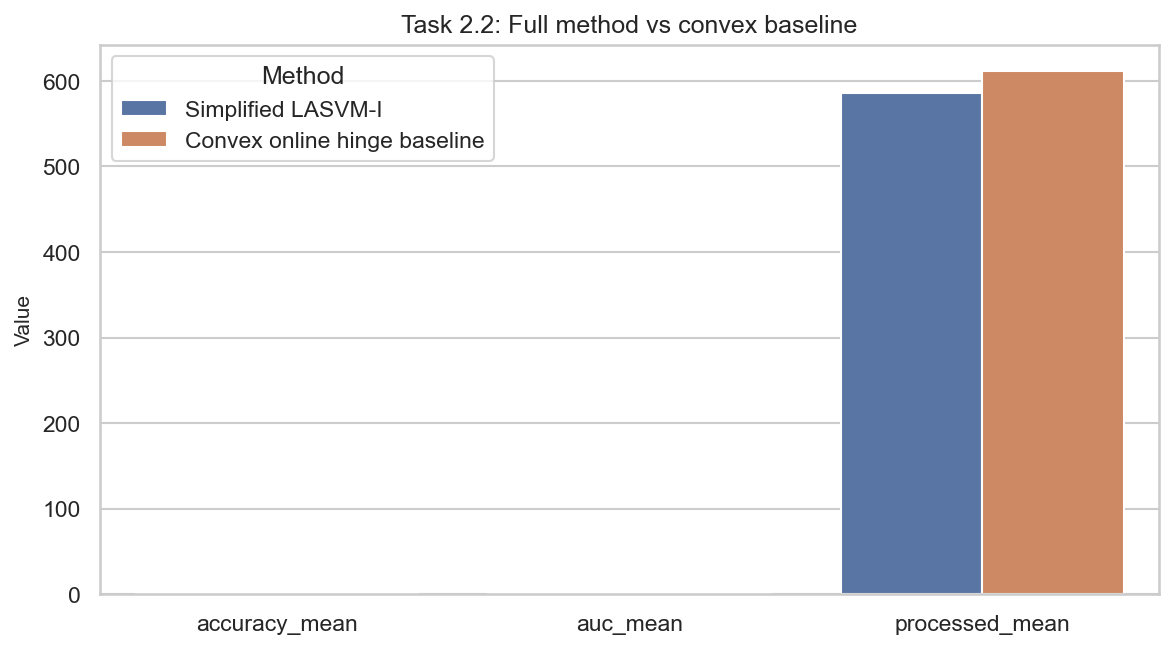

In [3]:
comparison_barplot(
    summary_table[['method', 'accuracy_mean', 'auc_mean', 'processed_mean']],
    ['accuracy_mean', 'auc_mean', 'processed_mean'],
    'Task 2.2: Full method vs convex baseline',
    RESULTS_DIR / 'task_2_2_metric_comparison.png',
)

This figure is the simplest way to show what the reproduction actually achieved. On my toy setup, the filtering rule mainly shows up as a reduction in processed examples, while the test accuracy stays in the same range as the convex baseline instead of jumping dramatically.

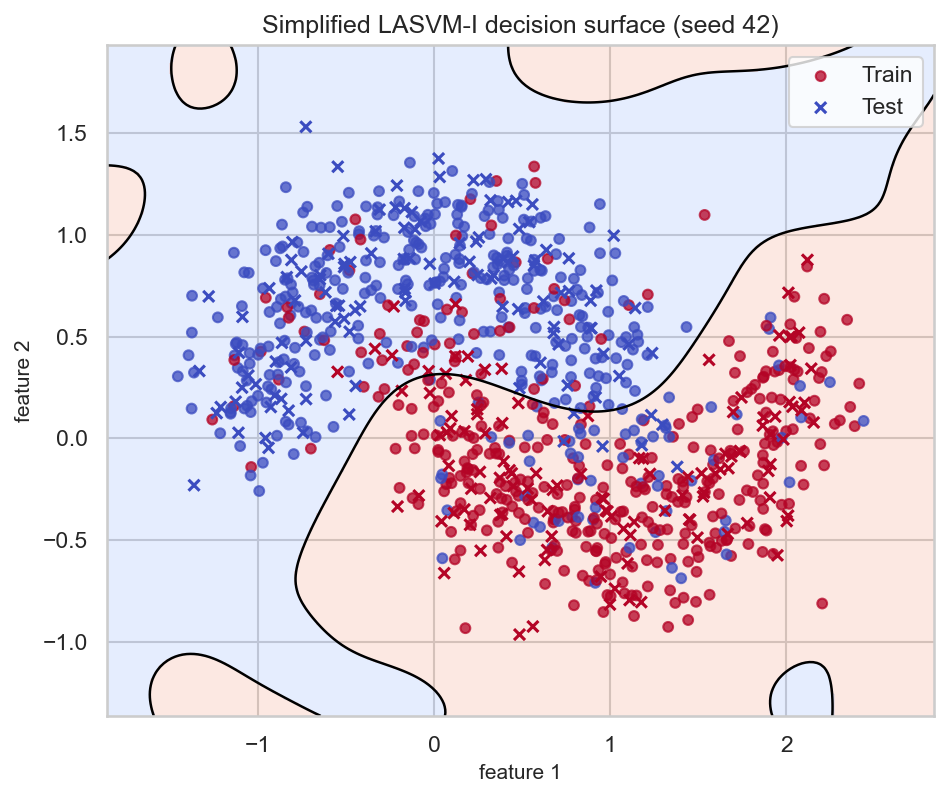

In [4]:
seed42_artifact = next(item for item in full_artifacts if item['seed'] == 42)
plot_decision_surface(seed42_artifact, RESULTS_DIR / 'task_2_2_seed42_boundary.png', 'Simplified LASVM-I decision surface (seed 42)')

This decision-surface plot is my visual check that the model learned a nonlinear boundary rather than a degenerate separator. The paper's original solver is more sophisticated than my approximation, but the figure still lets me inspect whether the margin-filtering idea produced a sensible classifier on a noisy nonlinear dataset.

## Short Interpretation

The filtering mechanism is clearly active in this reproduction: the simplified LASVM-I learner processed fewer examples than the convex online baseline while keeping test accuracy in nearly the same band. I do not see a dramatic accuracy gain on this moderate-noise toy setup, which is an honest sign that my approximation is lighter than the original paper and that the benefit here is mostly efficiency plus a slightly more selective training stream. Even so, the experiment does reproduce the central paper idea that the learner does not have to react to every badly placed point.